# Synthetic demand from any distribution

`DemandGenerator` ships with constant, normal, seasonal, and trend demand, and it can fit a normal to a history. When you need something else (Poisson counts, intermittent sales, a resampled history, demand that remembers yesterday) you write a **sampler**: a small function that draws demand, which the generator turns into a complete, seeded, validated demand table.

This notebook first tours the built-in patterns, then builds a three-product panel with samplers, one sampler for all products and one sampler per product, and runs it through the engine.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast.core import InventoryStateDataFrame, SimulationEngine
from stockcast.evaluation import InventoryEvaluator, fill_rate
from stockcast.policies import OrderUpToPolicy
from stockcast.utils import DemandGenerator

## 1. The generator owns the calendar and the seed

The generator is declared once: which SKUs, the date of period 0, the period length, and the seed. Every table it produces uses that calendar and draws from that one seeded random stream.

In [2]:
skus = ["tea_250g", "coffee_1kg", "honey_jar"]
opening_date = pd.Timestamp("2026-01-05")  # the day we count the shelf
n_periods = 28  # four weeks of daily demand

generator_settings = {
    "first_date": opening_date + pd.Timedelta(days=1),  # date of period 0
    "freq": "D",
    "random_seed": 9,
}
generator = DemandGenerator(skus, **generator_settings)

The calendar is checked, not guessed. `first_date` must be a period date of `freq`, so a weekly generator anchored on Mondays (`"W-MON"`) needs a Monday. This one starts on 2026-01-12. Below, `plot_demand` draws every generated table the same way: one panel per SKU.

In [3]:
DEMAND_COLOR = "#167d9a"


def plot_demand(table, title, ymax=None, ticks=None, step=True):
    """Draw one panel per SKU for a demand table.

    The y-axis runs from zero to `ymax` (the largest value by default). Pass
    `ymax` to share a scale across figures, `ticks` to set the date ticks, and
    `step=False` for a line with markers.
    """
    ymax = 1.05 * table["y"].max() if ymax is None else ymax
    fig, axes = plt.subplots(len(skus), 1, figsize=(8, 5.4), sharex=True, sharey=True)
    for ax, sku in zip(axes, skus):
        series = table[table["unique_id"] == sku]
        if step:
            ax.step(series["date"], series["y"], where="mid", color=DEMAND_COLOR)
        else:
            ax.plot(series["date"], series["y"], color=DEMAND_COLOR, marker="o")
        ax.set_ylim(0, ymax)
        ax.set_title(sku, loc="left", fontsize=10)
        ax.set_ylabel("Units")
        ax.spines[["top", "right"]].set_visible(False)
    if ticks is not None:
        axes[-1].set_xticks(ticks)
    axes[-1].set_xlabel("Date")
    fig.suptitle(title, x=0.01, ha="left")
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

    unique_id          y  period       date
0    tea_250g  45.985815       0 2026-01-12
1  coffee_1kg  55.717265       0 2026-01-12
2   honey_jar  48.028240       0 2026-01-12


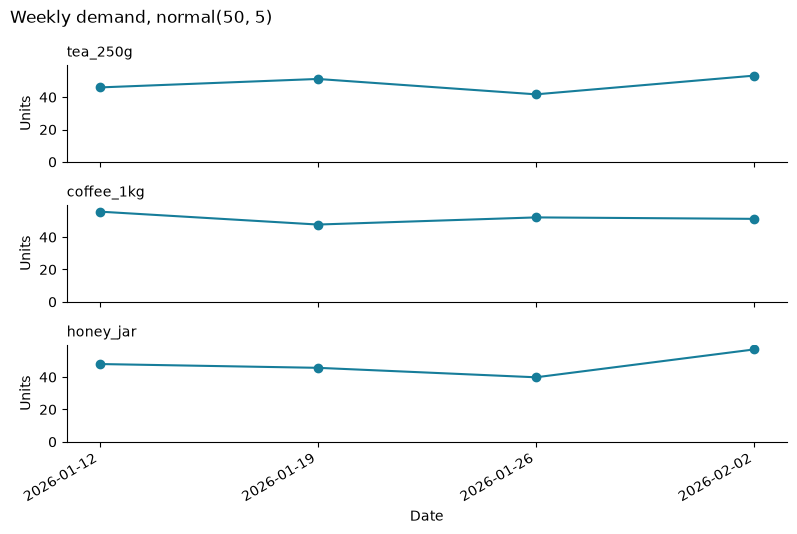

In [4]:
weekly_generator = DemandGenerator(
    skus,
    first_date=pd.Timestamp("2026-01-12"),  # a Monday
    freq="W-MON",
    random_seed=9,
)
weekly = weekly_generator.normal(n_periods=4, mean=50.0, std=5.0)
print(weekly.head(3))
plot_demand(
    weekly,
    "Weekly demand, normal(50, 5)",
    ticks=weekly["date"].unique(),
    step=False,
)

## 2. Built-in patterns

Four built-in methods cover common demand shapes: `constant`, `normal`, `seasonal` and `trend`. Every parameter can be one value for all SKUs or a dict with one value per SKU. The examples below use a fresh generator with the same settings for each call, so they stay independent of the sampler examples later in the notebook.

In [5]:
def fresh_generator():
    return DemandGenerator(skus, **generator_settings)


patterns = {
    "Constant": fresh_generator().constant(
        n_periods=n_periods,
        value={"tea_250g": 5.0, "coffee_1kg": 3.0, "honey_jar": 1.0},
    ),
    "Normal": fresh_generator().normal(
        n_periods=n_periods,
        mean={"tea_250g": 7.0, "coffee_1kg": 4.0, "honey_jar": 3.0},
        std={"tea_250g": 2.0, "coffee_1kg": 1.0, "honey_jar": 0.5},
    ),
    "Seasonal (weekly cycle)": fresh_generator().seasonal(
        n_periods=n_periods,
        base=7.0,  # one value shared by all SKUs
        amplitude={"tea_250g": 3.0, "coffee_1kg": 1.0, "honey_jar": 0.0},
        season_length=7,
        std=0.5,
    ),
    "Trend": fresh_generator().trend(
        n_periods=n_periods,
        initial=3.0,
        growth_rate={"tea_250g": 0.2, "coffee_1kg": 0.0, "honey_jar": -0.05},
        std=0.3,
    ),
}

summary_by_pattern = pd.concat(
    {
        name: table.groupby("unique_id")["y"].agg(["mean", "min", "max"]).round(2)
        for name, table in patterns.items()
    },
    names=["pattern"],
)
print(summary_by_pattern)

                                    mean   min    max
pattern                 unique_id                    
Constant                coffee_1kg  3.00  3.00   3.00
                        honey_jar   1.00  1.00   1.00
                        tea_250g    5.00  5.00   5.00
Normal                  coffee_1kg  3.71  2.16   5.88
                        honey_jar   2.96  2.20   4.19
                        tea_250g    7.24  2.93  12.04
Seasonal (weekly cycle) coffee_1kg  6.85  5.49   8.30
                        honey_jar   6.96  6.20   8.19
                        tea_250g    7.06  3.85  11.10
Trend                   coffee_1kg  2.91  2.45   3.56
                        honey_jar   2.30  1.42   3.37
                        tea_250g    5.74  2.76   8.44


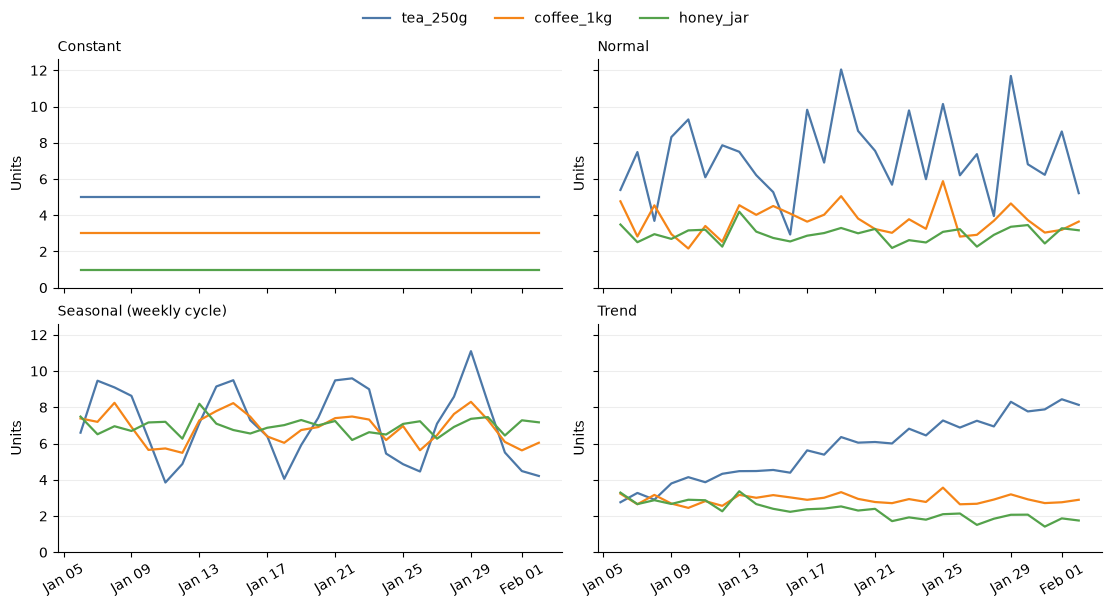

In [6]:
SKU_COLORS = {
    "tea_250g": "#4C78A8",
    "coffee_1kg": "#F58518",
    "honey_jar": "#54A24B",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 6),
    sharex=True,
    sharey=True,
    layout="constrained",
)
for axis, (name, table) in zip(axes.flat, patterns.items()):
    for sku in skus:
        series = table[table["unique_id"] == sku]
        axis.plot(
            series["date"],
            series["y"],
            color=SKU_COLORS[sku],
            linewidth=1.6,
            label=sku,
        )
    axis.set_title(name, loc="left", fontsize=10)
    axis.set_ylabel("Units")
    axis.grid(axis="y", alpha=0.22)
    axis.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylim(bottom=0)  # shared y-axis starts at zero
for axis in axes[1]:
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axis.tick_params(axis="x", labelrotation=30)
fig.legend(
    *axes.flat[0].get_legend_handles_labels(),
    loc="outside upper center",
    ncol=3,
    frameon=False,
)
plt.show()

Each panel keeps the same three SKUs. The constant lines are flat, the normal lines wobble around their means, the seasonal lines repeat a seven-day cycle whose swing depends on the SKU (honey has none), and the trend lines drift up, stay flat, or drift down.

### Fitting a normal to a history

`normal_from_history` estimates each SKU's mean and standard deviation from a table you already have, then draws new normal demand from them. Here the seasonal table above stands in for a history. The new table matches the history's level and spread but not its weekly cycle, because only a mean and a standard deviation are estimated. To keep a pattern like that, write a sampler.

           history       generated      
              mean   std      mean   std
unique_id                               
coffee_1kg    6.85  0.86      6.60  0.72
honey_jar     6.96  0.45      6.92  0.40
tea_250g      7.06  2.08      7.31  2.34


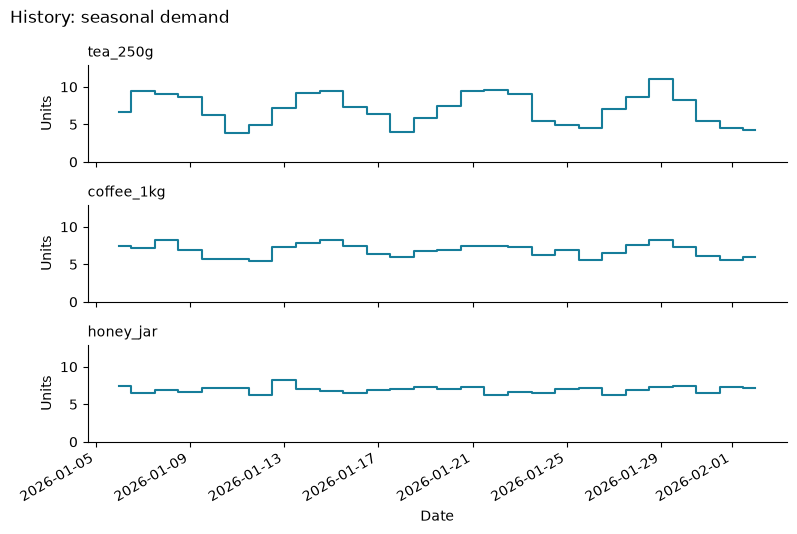

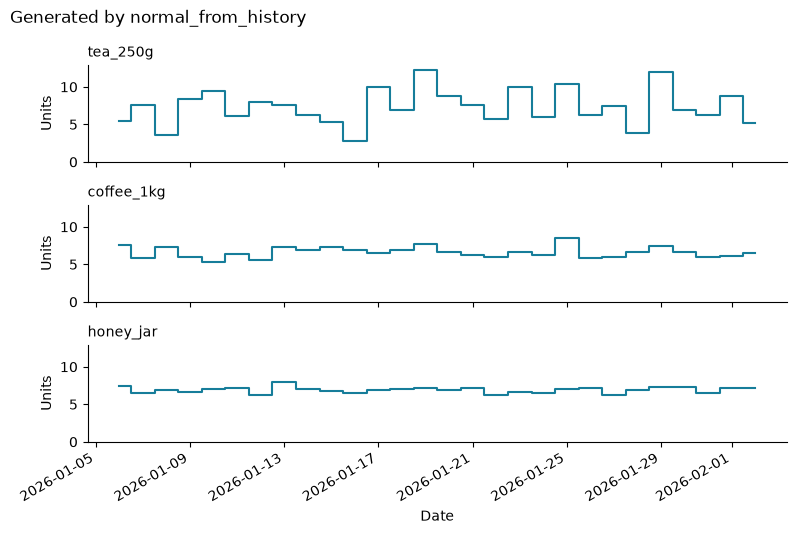

In [7]:
history = patterns["Seasonal (weekly cycle)"]
from_history = fresh_generator().normal_from_history(history, n_periods=n_periods)


def mean_and_std(table):
    return table.groupby("unique_id")["y"].agg(["mean", "std"]).round(2)


print(
    pd.concat(
        {"history": mean_and_std(history), "generated": mean_and_std(from_history)},
        axis=1,
    )
)

# Same y-axis for both figures, so level and spread can be compared.
shared_ymax = 1.05 * max(history["y"].max(), from_history["y"].max())
plot_demand(history, "History: seasonal demand", ymax=shared_ymax)
plot_demand(from_history, "Generated by normal_from_history", ymax=shared_ymax)

## 3. One sampler for the whole panel

A sampler has the signature `sampler(rng, periods)` and returns one value per period. `rng` is the generator's seeded stream; `periods` holds the period indices. Passed on its own, one sampler generates every SKU, each with its own independent draws.

In [8]:
def poisson(rng, periods):
    return rng.poisson(6.0, periods.size)


panel = generator.sample(n_periods=n_periods, sampler=poisson)
print(panel.head(6))

    unique_id    y  period       date
0    tea_250g  8.0       0 2026-01-06
1  coffee_1kg  3.0       0 2026-01-06
2   honey_jar  4.0       0 2026-01-06
3    tea_250g  3.0       1 2026-01-07
4  coffee_1kg  6.0       1 2026-01-07
5   honey_jar  9.0       1 2026-01-07


The result is the standard demand table: one row per SKU and period, with `unique_id`, `y`, `period`, and `date`. All three products follow the same Poisson(6) distribution but get different paths.

unique_id   coffee_1kg  honey_jar  tea_250g
date                                       
2026-01-06         3.0        4.0       8.0
2026-01-07         6.0        9.0       3.0
2026-01-08        12.0        3.0      14.0
2026-01-09         4.0        6.0       6.0


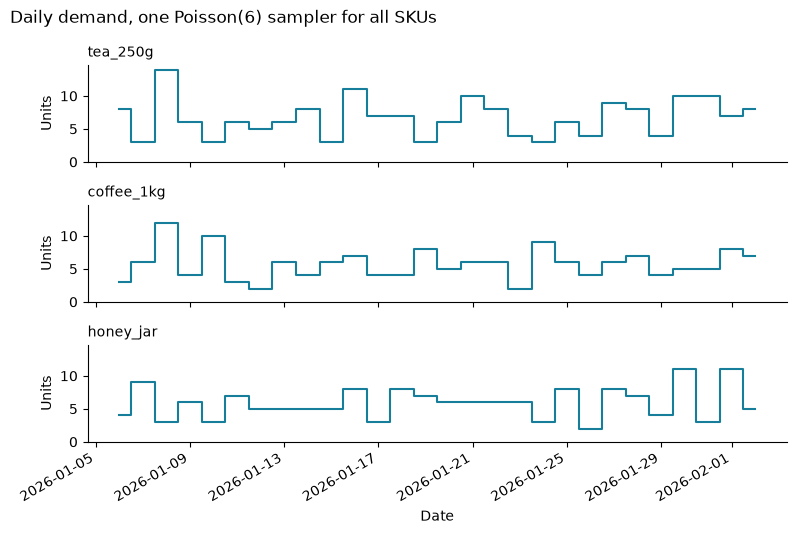

In [9]:
print(panel.pivot(index="date", columns="unique_id", values="y").head(4))
plot_demand(panel, "Daily demand, one Poisson(6) sampler for all SKUs")

## 4. One sampler per SKU

Real products rarely share one demand model. A dict assigns a sampler to each SKU, exactly like a dict of parameters:

- **tea** sells more on weekends: its Poisson rate depends on the period;
- **coffee** resamples its own sales history;
- **honey** is intermittent: it sells on about 30% of days, a few jars at a time.

In [10]:
def busy_weekends(rng, periods):
    weekday = (opening_date + pd.to_timedelta(periods + 1, unit="D")).dayofweek
    rate = np.where(weekday >= 5, 9.0, 6.0)  # Saturday and Sunday
    return rng.poisson(rate)


coffee_history = np.array([2, 3, 1, 4, 2, 0, 3, 5, 2, 1, 3, 2, 4, 1])


def resample_history(rng, periods):
    return rng.choice(coffee_history, periods.size)


def intermittent(rng, periods):
    sells = rng.binomial(1, 0.3, periods.size)
    return sells * rng.poisson(3.0, periods.size)


samplers = {
    "tea_250g": busy_weekends,
    "coffee_1kg": resample_history,
    "honey_jar": intermittent,
}

In [11]:
demand = generator.sample(n_periods=n_periods, sampler=samplers)

summary = demand.groupby("unique_id")["y"].agg(
    mean="mean",
    zero_days=lambda y: int((y == 0).sum()),
    max="max",
)
print(summary.loc[skus])

                mean  zero_days   max
unique_id                            
tea_250g    7.000000          0  15.0
coffee_1kg  2.000000          4   4.0
honey_jar   1.285714         19   6.0


Tea averages about seven a day with weekend peaks, coffee stays within its historical range, and honey has many zero days. The figure shows the three shapes on one shared scale.

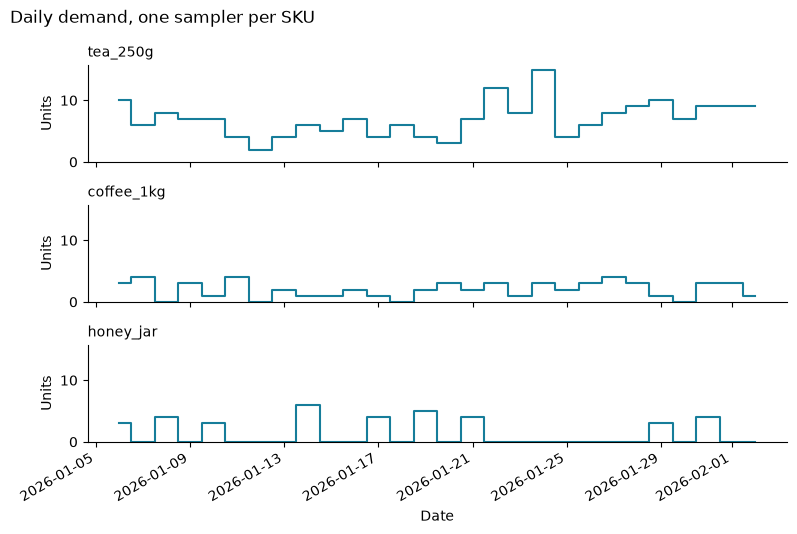

In [12]:
plot_demand(demand, "Daily demand, one sampler per SKU")

### A sampler that remembers

Because `sample` hands the sampler all periods at once, it can carry state from one period to the next. This sampler pulls demand back toward 6 units but keeps 70% of yesterday's deviation, so busy days tend to follow busy days. It is compared with independent Poisson(6) draws over 120 days.

In [13]:
def autocorrelated(rng, periods):
    level = 6.0
    demand = []
    for _ in periods:
        level = 6.0 + 0.7 * (level - 6.0) + rng.normal(0.0, 1.5)
        demand.append(max(level, 0.0))
    return demand


long_run = 120
independent = fresh_generator().sample(n_periods=long_run, sampler=poisson)
remembering = fresh_generator().sample(n_periods=long_run, sampler=autocorrelated)

for name, table in {"independent": independent, "autocorrelated": remembering}.items():
    tea = table[table["unique_id"] == "tea_250g"]["y"]
    print(f"{name:>14}: lag-1 autocorrelation of tea = {tea.autocorr(lag=1):.2f}")

   independent: lag-1 autocorrelation of tea = -0.09
autocorrelated: lag-1 autocorrelation of tea = 0.62


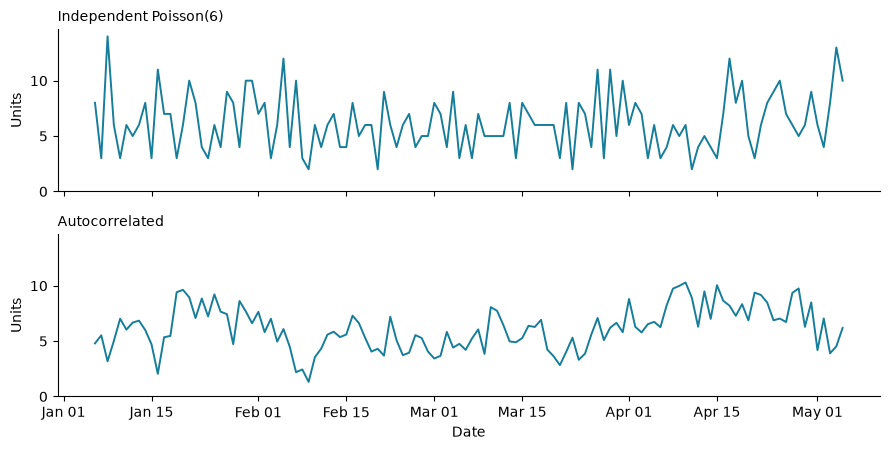

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True, sharey=True)
for axis, (name, table) in zip(
    axes,
    {"Independent Poisson(6)": independent, "Autocorrelated": remembering}.items(),
):
    series = table[table["unique_id"] == "tea_250g"]
    axis.plot(series["date"], series["y"], color=DEMAND_COLOR, linewidth=1.4)
    axis.set_title(name, loc="left", fontsize=10)
    axis.set_ylabel("Units")
    axis.spines[["top", "right"]].set_visible(False)
axes[0].set_ylim(bottom=0)  # shared y-axis starts at zero
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.tight_layout()
plt.show()

The independent draws jump between busy and quiet days, and their lag-1 autocorrelation is close to zero (-0.09 for tea). The remembering sampler moves in longer swings: its lag-1 autocorrelation for tea is 0.62.

## 5. Same seed, same panel

Because every sampler draws from the generator's `rng`, a new generator with the same seed reproduces the table exactly. That is what makes a synthetic experiment repeatable.

In [15]:
again = DemandGenerator(skus, **generator_settings)
pd.testing.assert_frame_equal(panel, again.sample(n_periods=n_periods, sampler=poisson))
print("identical demand tables")

identical demand tables


The generator also checks what every sampler returns: one finite number per period. A wrong length, non-numeric values, or `NaN` stop with a message naming the SKU. Negative draws follow `negative_demand_handling`, just as they do for the built-in methods: the default raises, `"clip_zero"` clips and warns.

## 6. Into the engine

The generated table goes straight into the engine as `demand_source`. We draw the four simulated weeks from a fresh generator with its own seed, so the run is reproducible and its path is a new draw from the same three models.

The policy is an order-up-to rule with lead time 2 and a review every 4 days. Its targets come from the same samplers: 10,000 planning paths over the 6-day protection window, drawn from a separate planning stream. Each path is summed first, then the 95% quantile of the totals is taken.

In [16]:
lead_time = 2
review_period = 4
horizon = lead_time + review_period  # 6-day protection window
n_paths = 10_000

planning_rng = np.random.default_rng(42)  # separate from the demand seed
# The sampler is called once per period of every path.
path_periods = np.tile(np.arange(horizon), n_paths)


def protection_target(sku):
    draws = samplers[sku](planning_rng, path_periods)
    path_totals = draws.reshape(n_paths, horizon).sum(axis=1)  # one total per path
    return np.quantile(path_totals, 0.95)


target = pd.DataFrame(
    {
        "unique_id": skus,
        "target": [protection_target(sku) for sku in skus],
        "target_end_date": opening_date + pd.Timedelta(days=horizon),
    }
)
print(target)

    unique_id  target target_end_date
0    tea_250g    53.0      2026-01-11
1  coffee_1kg    20.0      2026-01-11
2   honey_jar    13.0      2026-01-11


In [17]:
policy = OrderUpToPolicy(
    lead_time=lead_time,
    review_period=review_period,
    freq="D",
    service_level=0.95,
    allow_backorders=False,
    date_column="target_end_date",
)
policy.fit(target, target_column="target", forecast_origin=opening_date)

opening_stock = pd.DataFrame({"unique_id": skus, "on_hand": [30.0, 10.0, 5.0]})
empty_state = InventoryStateDataFrame(
    skus,
    max_lead_time=lead_time,
    allow_backorders=False,
)
inventory = empty_state.initialize_from_observed(
    opening_stock,
    on_hand_column="on_hand",
    opening_date=opening_date,
)

In [18]:
engine_generator = DemandGenerator(skus, **generator_settings)
engine_demand = engine_generator.sample(n_periods=n_periods, sampler=samplers)

result = SimulationEngine().run(
    policy=policy,
    demand_source=engine_demand,
    inventory=inventory,
    demand_source_name="three_samplers",  # optional label for the manifest
    random_seed=9,
)

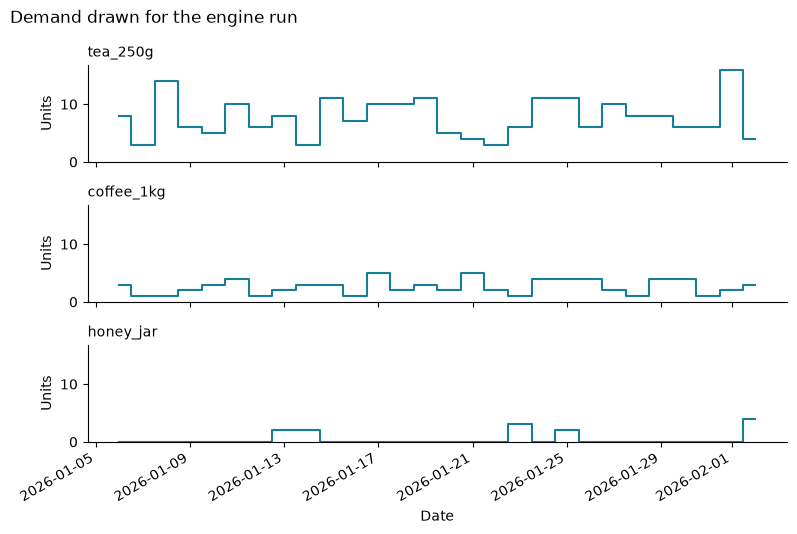

In [19]:
plot_demand(engine_demand, "Demand drawn for the engine run")

The event table shows how each product fared over the four weeks, with fill rate from `InventoryEvaluator`:

In [20]:
events = result.to_event_frame()
totals = events.groupby("unique_id")[
    ["demand", "fulfilled_units", "lost_sales_units"]
].sum()

evaluator = InventoryEvaluator()
evaluator.fit(simulation_result=result, window="scoring")
fill = evaluator.evaluate(metrics=[fill_rate], groupby=["unique_id"])
totals["fill_rate"] = fill.set_index("unique_id")["fill_rate"].round(3)
print(totals.loc[skus])

            demand  fulfilled_units  lost_sales_units  fill_rate
unique_id                                                       
tea_250g     216.0            216.0               0.0        1.0
coffee_1kg    73.0             73.0               0.0        1.0
honey_jar     13.0             13.0               0.0        1.0


All three products are fully served on this draw. Honey, the intermittent product, is the one to watch: its sales arrive in lumps, so on other draws a single six-day window can exceed even a 95% target. Swapping a sampler is all it takes to stress a policy on a different demand shape.

The run manifest records where the demand came from: the source name, the seed, a fingerprint of the table, and the generator's negative-draw handling.

In [21]:
source = result.run_manifest["demand_source"]
print({key: source[key] for key in ["name", "type", "rows", "random_seed"]})
print(source["generation_provenance"])

{'name': 'three_samplers', 'type': 'dataframe', 'rows': 84, 'random_seed': 9}
{'negative_demand_handling': 'raise', 'clipped_negative_count': 0, 'minimum_clipped_value': None}
